# Import segment wise correlation matrices

In [1]:
from pathlib import Path
import pandas as pd

# Folder containing all segment-level correlation matrices
DATA_ROOT = Path("correlation_matrices_segment_wise_(notAbsolute)")

matrix_files = sorted(path for path in DATA_ROOT.rglob("*.csv") if path.is_file())

if not matrix_files:
    raise FileNotFoundError(f"No CSV files found in '{DATA_ROOT}'.")

correlation_matrices = {}
for path in matrix_files:
    relative_key = str(path.relative_to(DATA_ROOT))
    df = pd.read_csv(path, index_col=0)
    numeric = df.apply(pd.to_numeric, errors="coerce").to_numpy()
    correlation_matrices[relative_key] = numeric

print(f"Loaded {len(correlation_matrices)} segment-level correlation matrices from CSV files.")
print(f"Example key: {next(iter(correlation_matrices))}")

Loaded 2632 segment-level correlation matrices from CSV files.
Example key: sub-NORB00001/ses-1/sub-NORB00001_ses-1_segment-01_pearson_corr.csv


# Absolute valued version of each segment-level correlation matrix

In [ ]:
import numpy as np
import pandas as pd

abs_correlation_matrices = {}
for key, matrix in correlation_matrices.items():
    matrix_array = np.asarray(matrix)
    try:
        numeric_matrix = matrix_array.astype(float)
    except ValueError:
        numeric_matrix = pd.DataFrame(matrix_array).apply(pd.to_numeric, errors="coerce").to_numpy()

    abs_correlation_matrices[key] = np.abs(numeric_matrix)

print(f"Converted {len(abs_correlation_matrices)} matrices to absolute values.")
print(f"Example key: {next(iter(abs_correlation_matrices))}")

Converted 2632 matrices to absolute values.
Example key: sub-NORB00001/ses-1/sub-NORB00001_ses-1_segment-01_pearson_corr.csv


# Betweenness centrality for each node in each segment
* Distance on each edge is defined as 1 / corr_value

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx

node_betweenness_by_segment = {}
segment_rows = []

for segment_key, corr_matrix in abs_correlation_matrices.items():
    corr = np.asarray(corr_matrix, dtype=float)

    if corr.ndim != 2 or corr.shape[0] != corr.shape[1]:
        continue

    corr = corr.copy()
    np.fill_diagonal(corr, 0.0)

    valid_edges = np.isfinite(corr) & (corr > 0)
    distance_matrix = np.zeros_like(corr, dtype=float)
    distance_matrix[valid_edges] = 1.0 / corr[valid_edges]

    graph = nx.from_numpy_array(distance_matrix)
    betweenness = nx.betweenness_centrality(graph, weight="weight", normalized=True)

    node_betweenness_by_segment[segment_key] = betweenness

    for node_index, bc_value in betweenness.items():
        segment_rows.append(
            {
                "segment": segment_key,
                "node": int(node_index),
                "betweenness": float(bc_value),
            }
        )

node_betweenness_df = pd.DataFrame(segment_rows)

print(f"Computed betweenness centrality for {len(node_betweenness_by_segment)} segments.")
print(f"Total node-level rows: {len(node_betweenness_df)}")
node_betweenness_df.head()

Computed betweenness centrality for 2632 segments.
Total node-level rows: 50008


,segment,node,betweenness
0,sub-NORB00001/ses-1/sub-NORB00001_ses-1_segmen...,0,0.000000
1,sub-NORB00001/ses-1/sub-NORB00001_ses-1_segmen...,1,0.000000
2,sub-NORB00001/ses-1/sub-NORB00001_ses-1_segmen...,2,0.006536
3,sub-NORB00001/ses-1/sub-NORB00001_ses-1_segmen...,3,0.000000
4,sub-NORB00001/ses-1/sub-NORB00001_ses-1_segmen...,4,0.000000


# Average node betweenness across segments within each session

In [ ]:
session_node_betweenness_df = node_betweenness_df.copy()

# Expected segment format: sub-XXX/ses-Y/<file>.csv
session_node_betweenness_df["subject"] = session_node_betweenness_df["segment"].str.split("/").str[0]
session_node_betweenness_df["session"] = session_node_betweenness_df["segment"].str.split("/").str[1]
session_node_betweenness_df["subject_session"] = (
    session_node_betweenness_df["subject"] + "/" + session_node_betweenness_df["session"]
)

session_node_betweenness_df = (
    session_node_betweenness_df
    .groupby(["subject_session", "subject", "session", "node"], as_index=False)["betweenness"]
    .mean()
    .rename(columns={"betweenness": "avg_betweenness"})
)

# Optional dictionary form: {subject/session: {node: avg_betweenness}}
session_betweenness_by_session = {
    subject_session: grp.set_index("node")["avg_betweenness"].to_dict()
    for subject_session, grp in session_node_betweenness_df.groupby("subject_session")
}

print(f"Computed session-level averages for {session_node_betweenness_df['subject_session'].nunique()} sessions.")
print(f"Total session-node rows: {len(session_node_betweenness_df)}")
session_node_betweenness_df.head()

Computed session-level averages for 125 sessions.
Total session-node rows: 2375


,subject_session,subject,session,node,avg_betweenness
0,sub-NORB00001/ses-1,sub-NORB00001,ses-1,0,0.004493
1,sub-NORB00001/ses-1,sub-NORB00001,ses-1,1,0.005106
2,sub-NORB00001/ses-1,sub-NORB00001,ses-1,2,0.005515
3,sub-NORB00001/ses-1,sub-NORB00001,ses-1,3,0.012663
4,sub-NORB00001/ses-1,sub-NORB00001,ses-1,4,0.061275


# Pairwise weighted Jaccard similarity for each node across subject-session pairs

In [ ]:
from itertools import combinations
import numpy as np
import pandas as pd

# Similarity is defined as min(a, b) / max(a, b) for two betweenness values a and b.
# When both values are 0, the similarity is defined as 1.0.
weighted_jaccard_rows = []

for node, node_group in session_node_betweenness_df.groupby("node", sort=True):
    node_values = node_group.set_index("subject_session")["avg_betweenness"]
    subject_sessions = node_values.index.to_list()

    for subject_session_a, subject_session_b in combinations(subject_sessions, 2):
        value_a = float(node_values.loc[subject_session_a])
        value_b = float(node_values.loc[subject_session_b])
        denominator = max(value_a, value_b)
        similarity = 1.0 if denominator == 0 else min(value_a, value_b) / denominator

        weighted_jaccard_rows.append(
            {
                "node": int(node),
                "subject_session_a": subject_session_a,
                "subject_session_b": subject_session_b,
                "betweenness_a": value_a,
                "betweenness_b": value_b,
                "weighted_jaccard_similarity": similarity,
            }
        )

weighted_jaccard_df = pd.DataFrame(weighted_jaccard_rows)
weighted_jaccard_by_node = {
    node: grp.reset_index(drop=True)
    for node, grp in weighted_jaccard_df.groupby("node")
}

print(f"Computed weighted Jaccard similarity for {weighted_jaccard_df['node'].nunique()} nodes.")
print(f"Total pairwise rows: {len(weighted_jaccard_df)}")
weighted_jaccard_df.head()

Computed weighted Jaccard similarity for 19 nodes.
Total pairwise rows: 147250


,node,subject_session_a,subject_session_b,betweenness_a,betweenness_b,weighted_jaccard_similarity
0,0,sub-NORB00001/ses-1,sub-NORB00003/ses-1,0.004493,0.005084,0.883929
1,0,sub-NORB00001/ses-1,sub-NORB00005/ses-1,0.004493,0.001937,0.430976
2,0,sub-NORB00001/ses-1,sub-NORB00006/ses-1,0.004493,0.000000,0.000000
3,0,sub-NORB00001/ses-1,sub-NORB00007/ses-1,0.004493,0.015251,0.294643
4,0,sub-NORB00001/ses-1,sub-NORB00008/ses-1,0.004493,0.002490,0.554113


# Heatmap of weighted Jaccard similarity for session 1 subjects with multiple sessions

Session 1 subjects used: 21
Heatmap shape: (210, 19)
Largest age difference: 0.2070
Smallest age difference: 0.0000


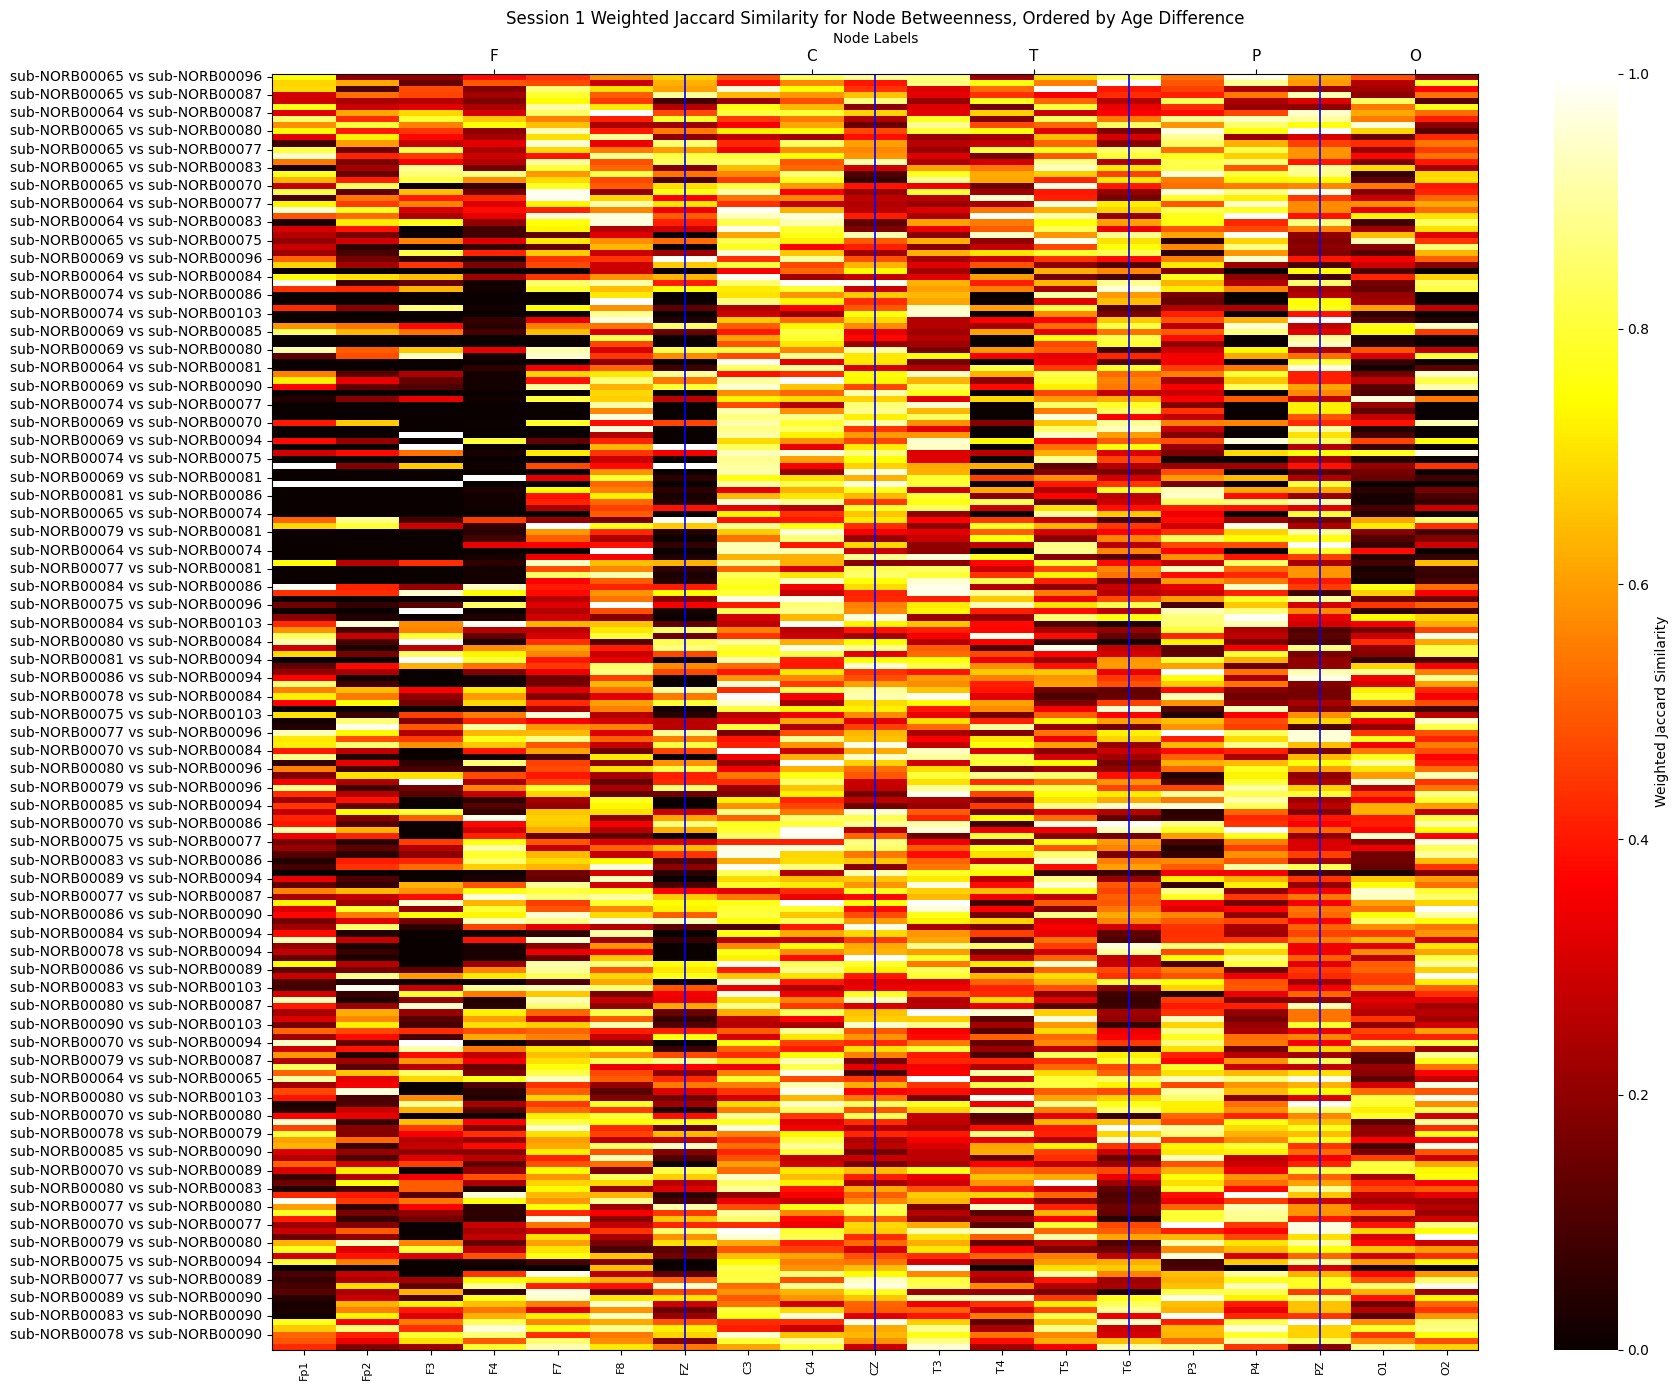

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Rows: subject pairs sorted by absolute age difference
# Columns: node labels ordered by F, C, T, P, O
age_df = pd.read_csv("age_acq_time_sorted.csv")
age_lookup = dict(zip(age_df["label"], age_df["age_acq_time"]))

# Read node labels directly from the correlation-matrix CSV header
node_labels = pd.read_csv(matrix_files[0], index_col=0, nrows=0).columns.tolist()
node_label_to_index = {label: i for i, label in enumerate(node_labels)}
node_order = [
    label
    for band in ["F", "C", "T", "P", "O"]
    for label in node_labels
    if label.upper().startswith(band)
]
node_order = [label for label in node_order if label in node_labels]
node_order_indices = [node_label_to_index[label] for label in node_order]

# Session 1 only, restricted to subjects that have multiple sessions
multi_session_subjects = (
    session_node_betweenness_df.groupby("subject")["session"]
    .nunique()
    .loc[lambda s: s > 1]
    .index
    .tolist()
)

session1_df = session_node_betweenness_df[
    (session_node_betweenness_df["session"] == "ses-1")
    & (session_node_betweenness_df["subject"].isin(multi_session_subjects))
    & (session_node_betweenness_df["node"].isin(node_order_indices))
].copy()

session1_pivot = session1_df.pivot(index="subject", columns="node", values="avg_betweenness")
valid_subjects = [subject for subject in session1_pivot.index if f"{subject}_ses-1" in age_lookup]
valid_subjects = sorted(valid_subjects)

heatmap_rows = []
for subject_a, subject_b in combinations(valid_subjects, 2):
    age_difference = abs(age_lookup[f"{subject_a}_ses-1"] - age_lookup[f"{subject_b}_ses-1"])
    similarity_values = []

    for node_index in node_order_indices:
        value_a = float(session1_pivot.loc[subject_a, node_index])
        value_b = float(session1_pivot.loc[subject_b, node_index])
        denominator = max(value_a, value_b)
        similarity = 1.0 if denominator == 0 else min(value_a, value_b) / denominator
        similarity_values.append(similarity)

    heatmap_rows.append(
        {
            "pair_label": f"{subject_a} vs {subject_b}",
            "age_difference": age_difference,
            "values": similarity_values,
        }
    )

heatmap_rows = sorted(heatmap_rows, key=lambda item: item["age_difference"], reverse=True)
weighted_jaccard_heatmap_df = pd.DataFrame(
    [item["values"] for item in heatmap_rows],
    index=[item["pair_label"] for item in heatmap_rows],
    columns=node_order,
)

print(f"Session 1 subjects used: {len(valid_subjects)}")
print(f"Heatmap shape: {weighted_jaccard_heatmap_df.shape}")
if heatmap_rows:
    print(f"Largest age difference: {heatmap_rows[0]['age_difference']:.4f}")
    print(f"Smallest age difference: {heatmap_rows[-1]['age_difference']:.4f}")

plt.figure(figsize=(18, 14))
ax = sns.heatmap(
    weighted_jaccard_heatmap_df,
    cmap="hot",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Weighted Jaccard Similarity"},
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)

# Add band labels on a top axis and draw separators between bands
node_band_keys = [label[0].upper() for label in node_order]
band_order = ["F", "C", "T", "P", "O"]
ordered_bands = [band for band in band_order if band in node_band_keys]

band_positions = []
band_labels = []
band_boundaries = []
for band in ordered_bands:
    indices = [i for i, key in enumerate(node_band_keys) if key == band]
    if not indices:
        continue
    band_positions.append((indices[0] + indices[-1]) / 2.0 + 0.5)
    band_labels.append(band)
    band_boundaries.append(indices[-1] + 0.5)

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(band_positions)
ax_top.set_xticklabels(band_labels, fontsize=11)
ax_top.xaxis.set_ticks_position("top")
ax_top.xaxis.set_label_position("top")
ax_top.set_xlabel("Node Group")

for boundary in band_boundaries[:-1]:
    ax.axvline(x=boundary, color="blue", linewidth=1.2, zorder=3)

plt.title("Session 1 Weighted Jaccard Similarity for Node Betweenness, Ordered by Age Difference")
plt.xlabel("Node Labels")
plt.ylabel("Subject Pairs (sorted by absolute age difference)")
plt.tight_layout()
plt.savefig("weighted_jaccard_node_betweenness_session1.png", dpi=300, bbox_inches="tight")
plt.show()

# Heatmap of weighted Jaccard similarity for session 2 subjects with multiple sessions

Session 2 subjects used: 21
Heatmap shape: (210, 19)
Largest age difference: 0.3606
Smallest age difference: 0.0000


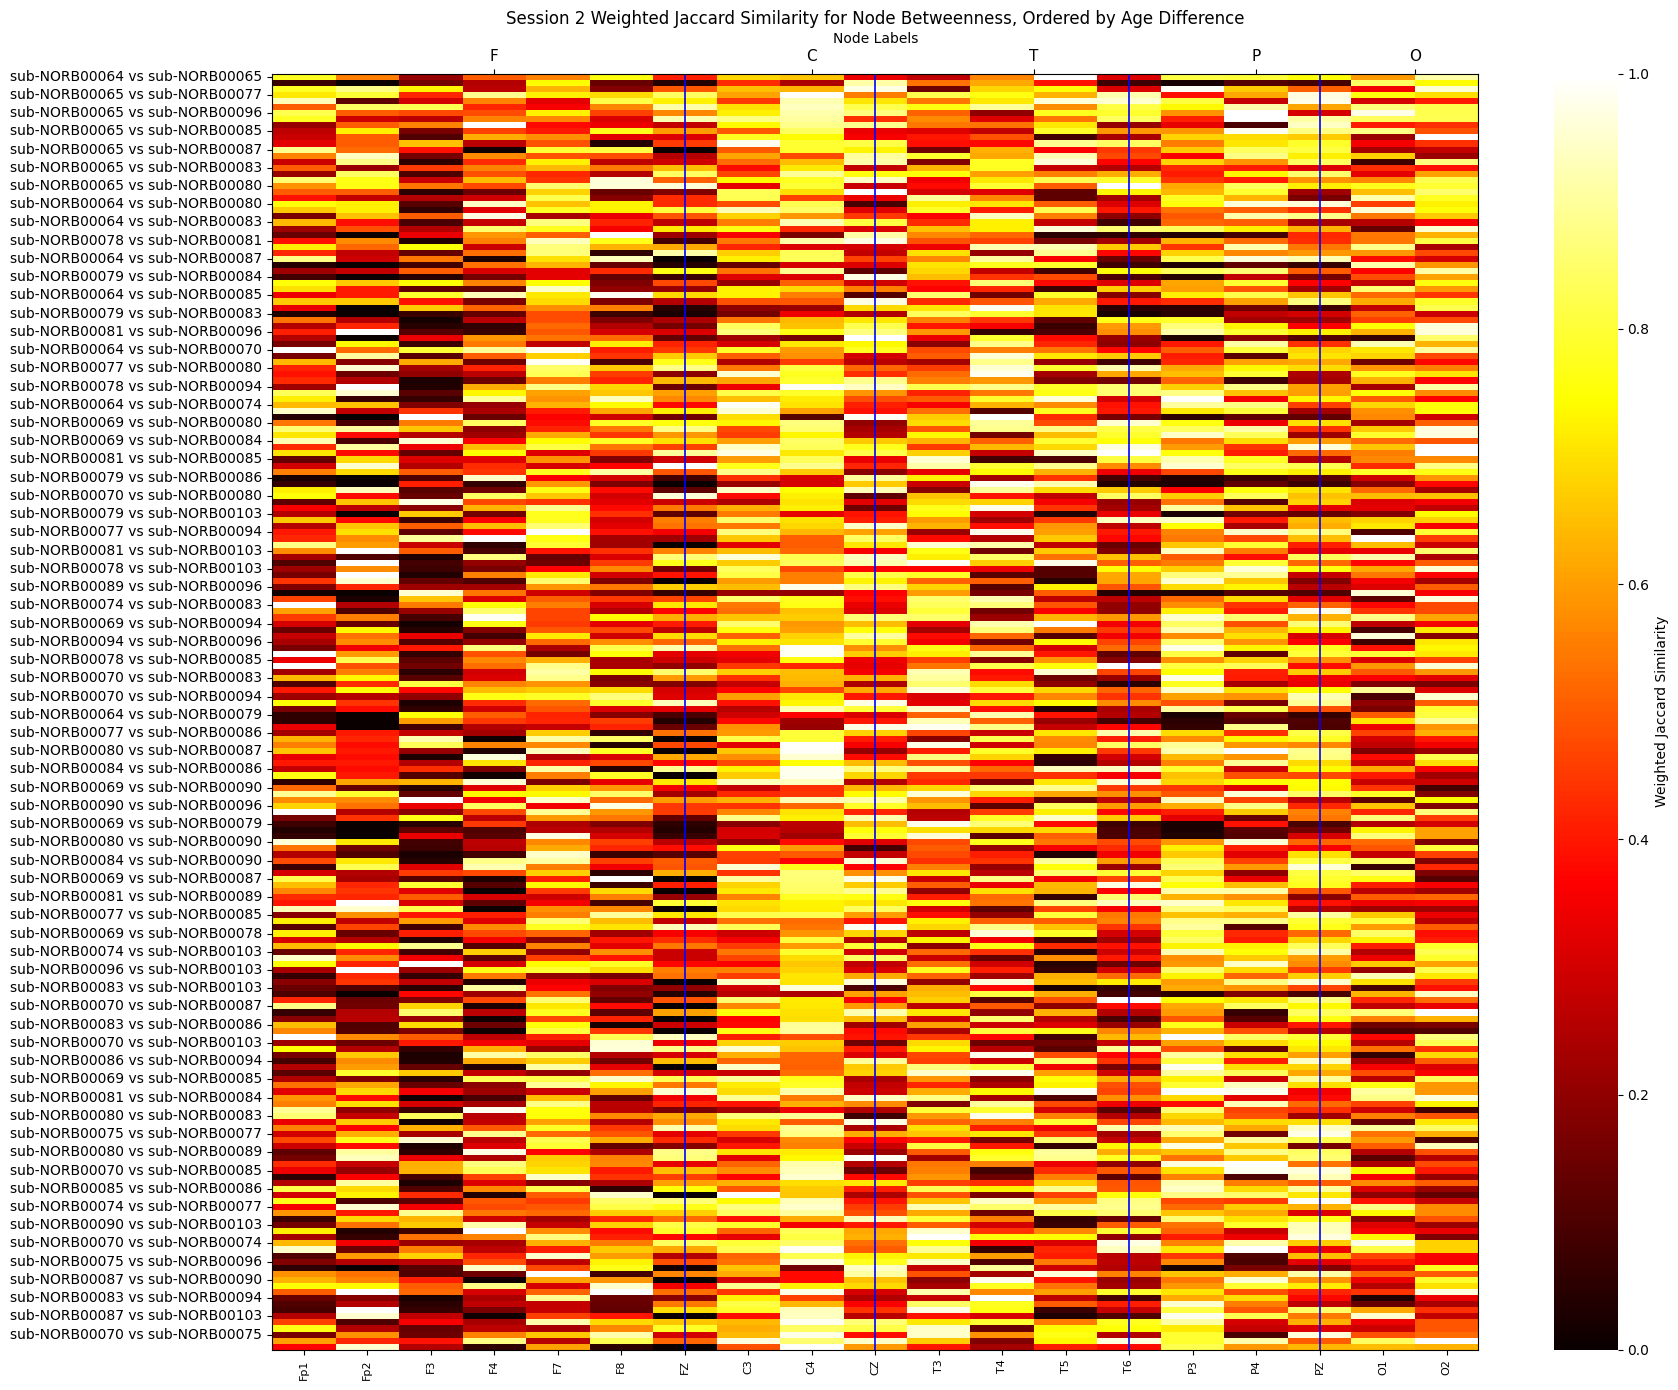

In [ ]:
# Rows: subject pairs sorted by absolute age difference
# Columns: node labels ordered by F, C, T, P, O
age_df = pd.read_csv("age_acq_time_sorted.csv")
age_lookup = dict(zip(age_df["label"], age_df["age_acq_time"]))

# Read node labels directly from the correlation-matrix CSV header
node_labels = pd.read_csv(matrix_files[0], index_col=0, nrows=0).columns.tolist()
node_label_to_index = {label: i for i, label in enumerate(node_labels)}
node_order = [
    label
    for band in ["F", "C", "T", "P", "O"]
    for label in node_labels
    if label.upper().startswith(band)
]
node_order = [label for label in node_order if label in node_labels]
node_order_indices = [node_label_to_index[label] for label in node_order]

# Session 2 only, restricted to subjects that have multiple sessions
multi_session_subjects = (
    session_node_betweenness_df.groupby("subject")["session"]
    .nunique()
    .loc[lambda s: s > 1]
    .index
    .tolist()
)

session2_df = session_node_betweenness_df[
    (session_node_betweenness_df["session"] == "ses-2")
    & (session_node_betweenness_df["subject"].isin(multi_session_subjects))
    & (session_node_betweenness_df["node"].isin(node_order_indices))
].copy()

session2_pivot = session2_df.pivot(index="subject", columns="node", values="avg_betweenness")
valid_subjects = [subject for subject in session2_pivot.index if f"{subject}_ses-2" in age_lookup]
valid_subjects = sorted(valid_subjects)

heatmap_rows = []
for subject_a, subject_b in combinations(valid_subjects, 2):
    age_difference = abs(age_lookup[f"{subject_a}_ses-2"] - age_lookup[f"{subject_b}_ses-2"])
    similarity_values = []

    for node_index in node_order_indices:
        value_a = float(session2_pivot.loc[subject_a, node_index])
        value_b = float(session2_pivot.loc[subject_b, node_index])
        denominator = max(value_a, value_b)
        similarity = 1.0 if denominator == 0 else min(value_a, value_b) / denominator
        similarity_values.append(similarity)

    heatmap_rows.append(
        {
            "pair_label": f"{subject_a} vs {subject_b}",
            "age_difference": age_difference,
            "values": similarity_values,
        }
    )

heatmap_rows = sorted(heatmap_rows, key=lambda item: item["age_difference"], reverse=True)
weighted_jaccard_session2_heatmap_df = pd.DataFrame(
    [item["values"] for item in heatmap_rows],
    index=[item["pair_label"] for item in heatmap_rows],
    columns=node_order,
)

print(f"Session 2 subjects used: {len(valid_subjects)}")
print(f"Heatmap shape: {weighted_jaccard_session2_heatmap_df.shape}")
if heatmap_rows:
    print(f"Largest age difference: {heatmap_rows[0]['age_difference']:.4f}")
    print(f"Smallest age difference: {heatmap_rows[-1]['age_difference']:.4f}")

plt.figure(figsize=(18, 14))
ax = sns.heatmap(
    weighted_jaccard_session2_heatmap_df,
    cmap="hot",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Weighted Jaccard Similarity"},
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)

# Add band labels on a top axis and draw separators between bands
node_band_keys = [label[0].upper() for label in node_order]
band_order = ["F", "C", "T", "P", "O"]
ordered_bands = [band for band in band_order if band in node_band_keys]

band_positions = []
band_labels = []
band_boundaries = []
for band in ordered_bands:
    indices = [i for i, key in enumerate(node_band_keys) if key == band]
    if not indices:
        continue
    band_positions.append((indices[0] + indices[-1]) / 2.0 + 0.5)
    band_labels.append(band)
    band_boundaries.append(indices[-1] + 0.5)

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(band_positions)
ax_top.set_xticklabels(band_labels, fontsize=11)
ax_top.xaxis.set_ticks_position("top")
ax_top.xaxis.set_label_position("top")
ax_top.set_xlabel("Node Group")

for boundary in band_boundaries[:-1]:
    ax.axvline(x=boundary, color="blue", linewidth=1.2, zorder=3)

plt.title("Session 2 Weighted Jaccard Similarity for Node Betweenness, Ordered by Age Difference")
plt.xlabel("Node Labels")
plt.ylabel("Subject Pairs (sorted by absolute age difference)")
plt.tight_layout()
plt.savefig("weighted_jaccard_node_betweenness_session2.png", dpi=300, bbox_inches="tight")
plt.show()